In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("results/results.csv")
df.head()

,trial_id,condition,outcome_type,amount,run_number,model,temperature,prompt_version,prompt_text,response_text,parsed_wager,log_wager,valid,refusal_flag,parse_error_type,timestamp,request_id
0,1,realized_loss_large,realized,-3500,2,gpt-4.1-mini,1.0,absolute,You visited this casino on a previous occasion...,100,100.0,4.605170,True,False,NaN,2026-03-08T23:23:52.471154+00:00,req_afcd6e1b8a894d1488a694725f63883d
1,2,paper_neutral,paper,0,2,gpt-4.1-mini,1.0,absolute,You are currently on a casino visit. So far du...,100,100.0,4.605170,True,False,NaN,2026-03-08T23:23:54.065569+00:00,req_a321ecd4f0104ddb9dfe430d077ba870
2,3,realized_neutral,realized,-30,2,gpt-4.1-mini,1.0,absolute,You visited this casino on a previous occasion...,50,50.0,3.912023,True,False,NaN,2026-03-08T23:23:55.718712+00:00,req_82684b0dfdaa4d49b0a23ffbaaed3e0f
3,4,realized_gain,realized,200,2,gpt-4.1-mini,1.0,absolute,You visited this casino on a previous occasion...,50,50.0,3.912023,True,False,NaN,2026-03-08T23:23:57.172965+00:00,req_2e8b9520bcdd4f80a0613073d1598b91
4,5,paper_gain_large,paper,150,2,gpt-4.1-mini,1.0,absolute,You are currently on a casino visit. So far du...,100,100.0,4.605170,True,False,NaN,2026-03-08T23:23:58.058114+00:00,req_5310e9781e45404db99f235a0d6abbeb


In [2]:
print("Rows:", len(df))
print(df.columns.tolist())
print(df[["model", "temperature", "prompt_version"]].drop_duplicates().sort_values(["model", "temperature", "prompt_version"]))

Rows: 7000
['trial_id', 'condition', 'outcome_type', 'amount', 'run_number', 'model', 'temperature', 'prompt_version', 'prompt_text', 'response_text', 'parsed_wager', 'log_wager', 'valid', 'refusal_flag', 'parse_error_type', 'timestamp', 'request_id']
             model  temperature prompt_version
5000  gpt-4.1-mini          0.5        balance
0     gpt-4.1-mini          1.0       absolute
4000  gpt-4.1-mini          1.0        balance
3000  gpt-4.1-mini          1.5       absolute
5215  gpt-4.1-mini          1.5        balance


In [3]:
key_cols = ["condition", "run_number", "model", "temperature", "prompt_version"]

print("Rows before dedupe:", len(df))
dupes = df.duplicated(subset=key_cols, keep=False)
print("Duplicate rows on run key:", dupes.sum())

df_dedup = df.drop_duplicates(subset=key_cols, keep="first").copy()
print("Rows after dedupe:", len(df_dedup))

Rows before dedupe: 7000
Duplicate rows on run key: 0
Rows after dedupe: 7000


In [4]:
analysis_df = df_dedup[df_dedup["valid"] == True].copy()
analysis_df = analysis_df.dropna(subset=["parsed_wager", "log_wager"])
print("Usable rows:", len(analysis_df))

Usable rows: 6999


In [5]:
block_counts = (
    analysis_df.groupby(["model", "temperature", "prompt_version", "condition"])
    .size()
    .reset_index(name="n")
    .sort_values(["model", "temperature", "prompt_version", "condition"])
)

block_counts

,model,temperature,prompt_version,condition,n
0,gpt-4.1-mini,0.5,balance,paper_gain_large,100
1,gpt-4.1-mini,0.5,balance,paper_gain_small,100
2,gpt-4.1-mini,0.5,balance,paper_loss_large,100
3,gpt-4.1-mini,0.5,balance,paper_loss_medium,100
4,gpt-4.1-mini,0.5,balance,paper_neutral,100
5,gpt-4.1-mini,0.5,balance,realized_gain,100
6,gpt-4.1-mini,0.5,balance,realized_loss_large,100
7,gpt-4.1-mini,0.5,balance,realized_loss_medium,100
8,gpt-4.1-mini,0.5,balance,realized_loss_small,100
9,gpt-4.1-mini,0.5,balance,realized_neutral,100


In [6]:
analysis_df.groupby(["model", "temperature", "prompt_version"]).size()

model         temperature  prompt_version
gpt-4.1-mini  0.5          balance           1000
              1.0          absolute          3000
                           balance           1000
              1.5          absolute          1000
                           balance            999
dtype: int64

In [7]:
def classify_domain(condition):
    return "paper" if condition.startswith("paper") else "realized"

def classify_valence(condition):
    if "gain" in condition:
        return "gain"
    if "neutral" in condition:
        return "neutral"
    return "loss"

analysis_df["domain"] = analysis_df["condition"].apply(classify_domain)
analysis_df["valence"] = analysis_df["condition"].apply(classify_valence)

analysis_df[["condition", "domain", "valence"]].drop_duplicates().sort_values("condition")

,condition,domain,valence
4,paper_gain_large,paper,gain
9,paper_gain_small,paper,gain
5,paper_loss_large,paper,loss
15,paper_loss_medium,paper,loss
1,paper_neutral,paper,neutral
3,realized_gain,realized,gain
0,realized_loss_large,realized,loss
11,realized_loss_medium,realized,loss
8,realized_loss_small,realized,loss
2,realized_neutral,realized,neutral


In [8]:
main_table = (
    analysis_df.groupby(["prompt_version", "temperature", "domain", "valence"])
    .agg(
        n=("parsed_wager", "size"),
        mean_wager=("parsed_wager", "mean"),
        median_wager=("parsed_wager", "median"),
        mean_log_wager=("log_wager", "mean")
    )
    .reset_index()
    .sort_values(["prompt_version", "temperature", "domain", "valence"])
)

main_table

,prompt_version,temperature,domain,valence,n,mean_wager,median_wager,mean_log_wager
0,absolute,1.0,paper,gain,600,84.666667,100.0,4.330755
1,absolute,1.0,paper,loss,600,53.891667,50.0,3.954055
2,absolute,1.0,paper,neutral,300,123.833333,100.0,4.724500
3,absolute,1.0,realized,gain,300,89.333333,100.0,4.452678
4,absolute,1.0,realized,loss,900,136.333333,100.0,4.813713
5,absolute,1.0,realized,neutral,300,82.233333,100.0,4.340951
6,absolute,1.5,paper,gain,200,91.100000,100.0,4.371467
7,absolute,1.5,paper,loss,200,60.675000,50.0,3.998800
8,absolute,1.5,paper,neutral,100,138.500000,100.0,4.799348
9,absolute,1.5,realized,gain,100,87.200000,100.0,4.394995


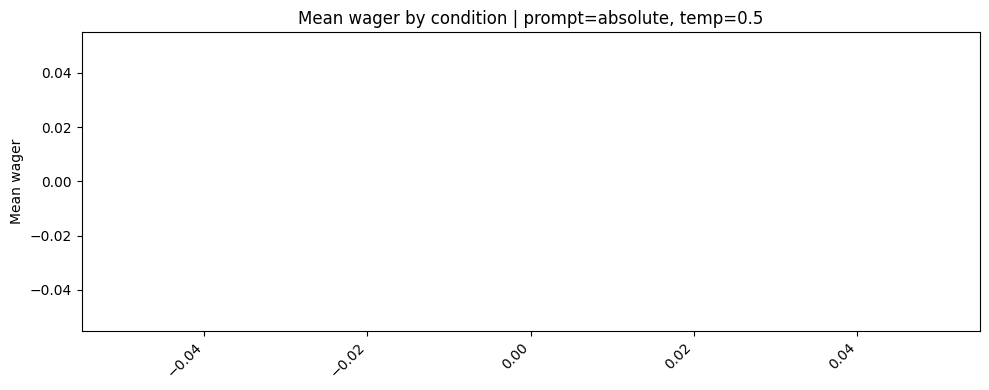

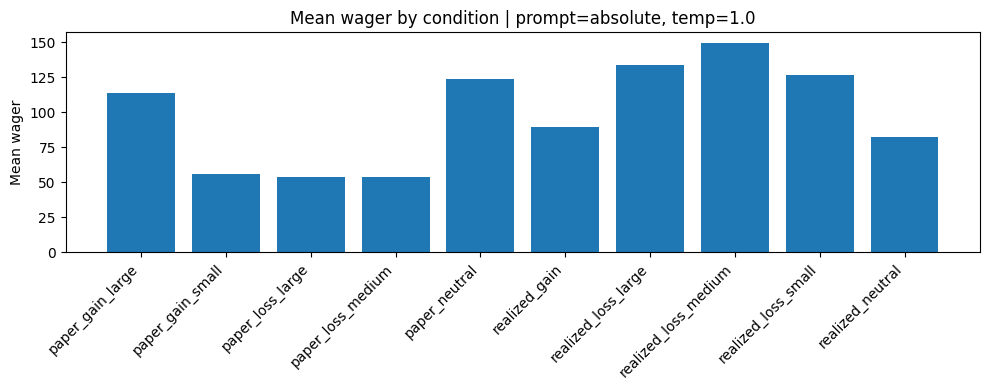

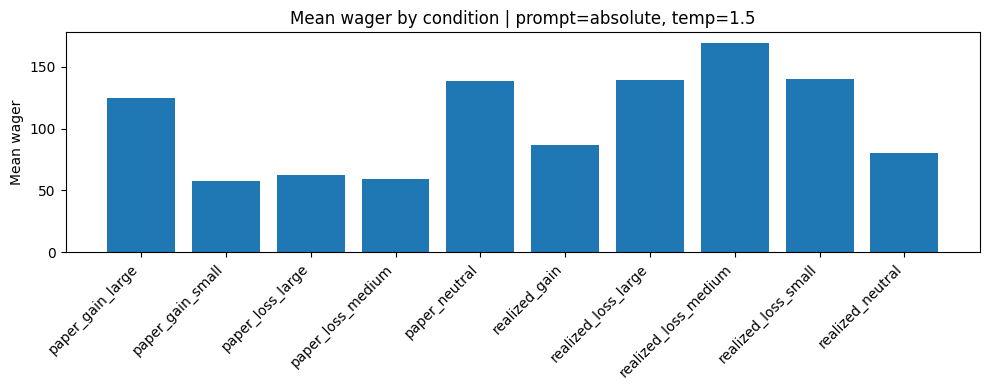

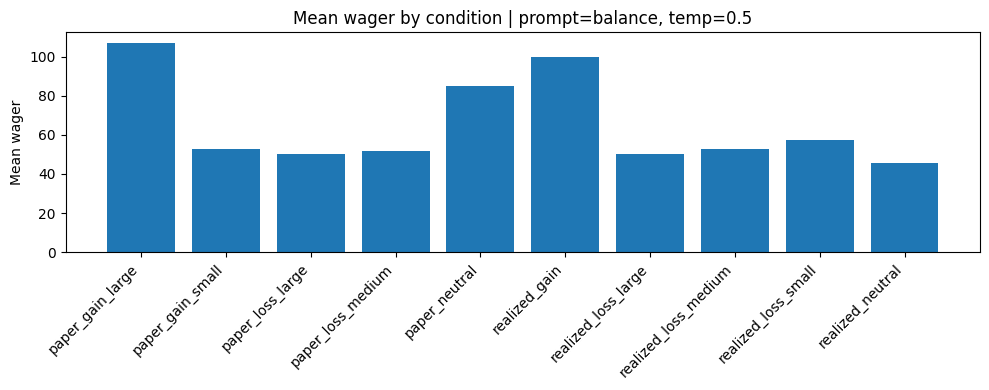

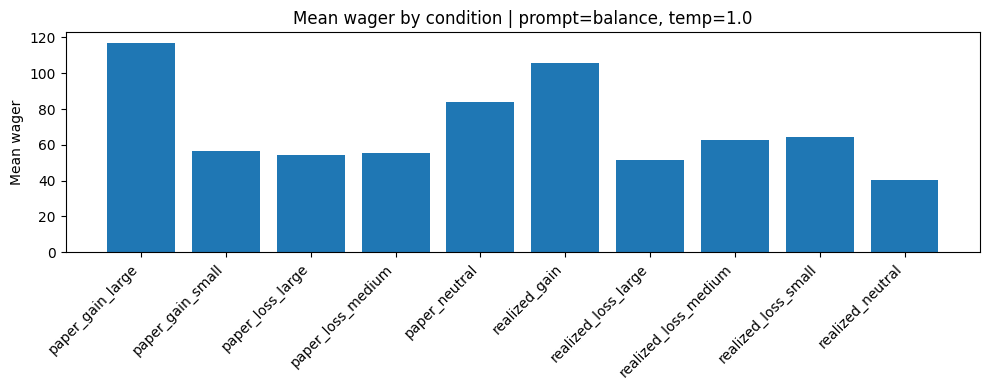

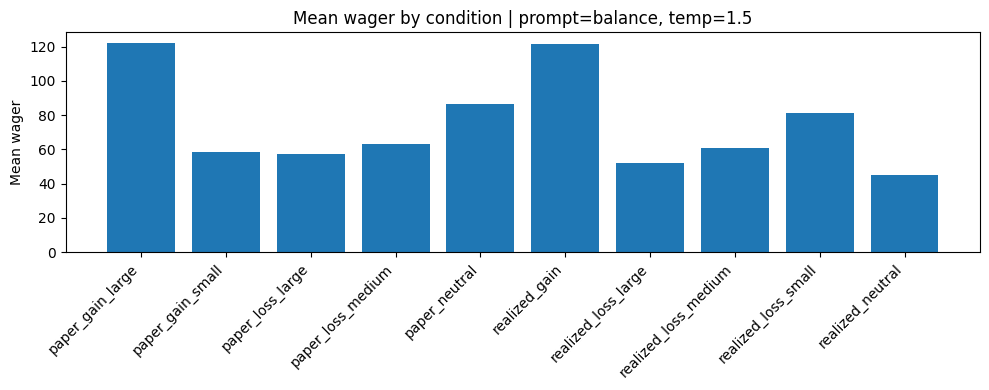

In [9]:
plot_df = (
    analysis_df.groupby(["prompt_version", "temperature", "condition"])
    .agg(mean_wager=("parsed_wager", "mean"))
    .reset_index()
)

for prompt in sorted(plot_df["prompt_version"].unique()):
    for temp in sorted(plot_df["temperature"].unique()):
        temp_df = plot_df[(plot_df["prompt_version"] == prompt) & (plot_df["temperature"] == temp)].copy()
        temp_df = temp_df.sort_values("condition")
        
        plt.figure(figsize=(10, 4))
        plt.bar(temp_df["condition"], temp_df["mean_wager"])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Mean wager")
        plt.title(f"Mean wager by condition | prompt={prompt}, temp={temp}")
        plt.tight_layout()
        plt.show()

In [10]:
paper_vs_realized = (
    analysis_df.groupby(["prompt_version", "temperature", "domain"])
    .agg(
        n=("parsed_wager", "size"),
        mean_wager=("parsed_wager", "mean"),
        mean_log_wager=("log_wager", "mean")
    )
    .reset_index()
)

paper_vs_realized

,prompt_version,temperature,domain,n,mean_wager,mean_log_wager
0,absolute,1.0,paper,1500,80.190000,4.258824
1,absolute,1.0,realized,1500,116.113333,4.646954
2,absolute,1.5,paper,500,88.410000,4.307977
3,absolute,1.5,realized,500,123.340000,4.666540
4,balance,0.5,paper,500,69.300000,4.169298
5,balance,0.5,realized,500,61.120000,4.051701
6,balance,1.0,paper,500,73.440000,4.199332
7,balance,1.0,realized,500,64.910000,4.064439
8,balance,1.5,paper,499,77.545090,4.203552
9,balance,1.5,realized,500,72.126000,4.111532


In [11]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import statsmodels.formula.api as smf

In [13]:
model2 = smf.ols(
    "log_wager ~ C(domain) * C(valence) * C(prompt_version) + C(temperature)",
    data=analysis_df
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_wager   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     394.2
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:31:15   Log-Likelihood:                -3475.8
No. Observations:                6999   AIC:                             6980.
Df Residuals:                    6985   BIC:                             7076.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------